# 02 — Preprocessing Pipeline
**PTB-XL ECG Dataset — Frankfurt University of Applied Sciences**

Full preprocessing pipeline implementing:
1. Load & alignment check
2. Missing value handling (linear interpolation)
3. Sampling rate consistency check
4. Z-score outlier clipping (±3σ)
5. Bandpass filter (0.5–40 Hz, Butterworth order 4)
6. Per-lead Z-score normalization
7. Sliding window segmentation
8. Multi-label encoding verification
9. Patient-wise train / val / test split
10. Training-time data augmentation
11. Save all outputs to `data/processed/`

In [1]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt

warnings.filterwarnings('ignore')

SAVE_DIR  = os.path.join('..', 'data', 'processed')
FS        = 100        # sampling rate Hz (change to 500 for high-res)
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

print("Imports OK ✅")
print(f"Working directory  : {os.path.abspath('.')}")
print(f"Processed data dir : {os.path.abspath(SAVE_DIR)}")

Imports OK ✅
Working directory  : /Users/muhammadfahadsiddiqui/HIS Project/notebooks
Processed data dir : /Users/muhammadfahadsiddiqui/HIS Project/data/processed


### Step 1 — Load Data & Verify Alignment
Load raw waveforms, metadata, and labels from `data/processed/`. Verify that every waveform has a matching metadata row using the ECG record index.

In [2]:
# ============================================================
# CELL 2: LOAD RAW DATA & VERIFY ALIGNMENT
# ============================================================

X_raw    = np.load(os.path.join(SAVE_DIR, 'X_raw.npy'))          # (N, samples, 12)
y_raw    = np.load(os.path.join(SAVE_DIR, 'y.npy'))               # (N, n_classes)
df       = pd.read_pickle(os.path.join(SAVE_DIR, 'metadata.pkl')) # full metadata

with open(os.path.join(SAVE_DIR, 'classes.pkl'), 'rb') as f:
    CLASSES = pickle.load(f)

# ── Alignment: metadata rows must match waveform count ────────
batch_df = df.iloc[:len(X_raw)].copy()

assert len(X_raw) == len(batch_df), (
    f"Mismatch! X_raw has {len(X_raw)} records but metadata has {len(batch_df)} rows."
)

print("=" * 55)
print("  DATA LOAD & ALIGNMENT CHECK")
print("=" * 55)
print(f"  Waveforms    : {X_raw.shape}  → (records, samples, leads)")
print(f"  Labels       : {y_raw.shape}")
print(f"  Metadata rows: {batch_df.shape}")
print(f"  Classes      : {CLASSES}")
print(f"  Alignment    : ✅ OK — {len(X_raw)} records matched")
print()
print("  Sample metadata columns:")
print(f"  {list(batch_df.columns[:8])} ...")

  DATA LOAD & ALIGNMENT CHECK
  Waveforms    : (200, 1000, 12)  → (records, samples, leads)
  Labels       : (200, 5)
  Metadata rows: (200, 28)
  Classes      : ['CD', 'HYP', 'MI', 'NORM', 'STTC']
  Alignment    : ✅ OK — 200 records matched

  Sample metadata columns:
  ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device'] ...


### Step 2 — Missing Value Handling
Detect any NaN values in the signal array and repair them using **linear interpolation** along the time axis to preserve temporal continuity.

In [3]:
# ============================================================
# CELL 3: MISSING VALUE DETECTION & LINEAR INTERPOLATION
# ============================================================

total_nan = np.isnan(X_raw).sum()
print(f"NaN values detected: {total_nan}")

if total_nan > 0:
    print("  Applying linear interpolation per lead per record...")
    X_interp = X_raw.copy()
    for rec_idx in range(X_interp.shape[0]):
        for lead_idx in range(X_interp.shape[2]):
            series = pd.Series(X_interp[rec_idx, :, lead_idx])
            if series.isna().any():
                X_interp[rec_idx, :, lead_idx] = (
                    series.interpolate(method='linear', limit_direction='both').values
                )
    remaining_nan = np.isnan(X_interp).sum()
    print(f"  Remaining NaN after interpolation: {remaining_nan}")
else:
    X_interp = X_raw.copy()
    print("  ✅ No NaN values — signals are clean, no interpolation needed.")

NaN values detected: 0
  ✅ No NaN values — signals are clean, no interpolation needed.


### Step 3 — Sampling Rate Consistency Check
Verify all records share the same temporal resolution. PTB-XL provides 100 Hz (1000 samples/10s) and 500 Hz (5000 samples/10s). This pipeline uses the batch loaded in `01_data_loading.ipynb`.

In [4]:
# ============================================================
# CELL 4: SAMPLING RATE CONSISTENCY CHECK
# ============================================================

n_samples   = X_interp.shape[1]
expected_fs = FS
expected_samples = expected_fs * 10   # 10-second recordings

print("=" * 55)
print("  SAMPLING RATE CONSISTENCY")
print("=" * 55)
print(f"  Expected FS          : {expected_fs} Hz")
print(f"  Expected samples     : {expected_samples} per record (10s)")
print(f"  Actual samples found : {n_samples}")

if n_samples == expected_samples:
    print(f"  ✅ All records consistent at {expected_fs} Hz")
else:
    print(f"  ⚠️  Mismatch! Got {n_samples} samples.")
    print(f"     If using 500 Hz data, set FS=500 in Cell 1 and re-run.")

print(f"\n  Signal duration per record : {n_samples / expected_fs:.1f} seconds")
print(f"  Leads per record           : {X_interp.shape[2]}")

  SAMPLING RATE CONSISTENCY
  Expected FS          : 100 Hz
  Expected samples     : 1000 per record (10s)
  Actual samples found : 1000
  ✅ All records consistent at 100 Hz

  Signal duration per record : 10.0 seconds
  Leads per record           : 12


### Step 4 — Amplitude Outlier Clipping (±3σ)
Clip values exceeding ±3 standard deviations computed per lead per record. This suppresses motion artifacts and noise spikes while preserving clinically meaningful waveform morphology.

In [5]:
# ============================================================
# CELL 5: Z-SCORE OUTLIER CLIPPING (±3σ)
# ============================================================

X_clipped = X_interp.copy()

n_clipped_total = 0
for rec_idx in range(X_clipped.shape[0]):
    for lead_idx in range(X_clipped.shape[2]):
        lead_signal = X_clipped[rec_idx, :, lead_idx]
        mean = lead_signal.mean()
        std  = lead_signal.std()
        if std == 0:
            continue
        lower = mean - 3 * std
        upper = mean + 3 * std
        n_clipped = np.sum((lead_signal < lower) | (lead_signal > upper))
        n_clipped_total += n_clipped
        X_clipped[rec_idx, :, lead_idx] = np.clip(lead_signal, lower, upper)

total_values = X_clipped.size
pct          = 100 * n_clipped_total / total_values

print(f"Outlier clipping (±3σ) complete:")
print(f"  Total values    : {total_values:,}")
print(f"  Values clipped  : {n_clipped_total:,}  ({pct:.3f}%)")
print(f"  ✅ Waveform morphology preserved")

Outlier clipping (±3σ) complete:
  Total values    : 2,400,000
  Values clipped  : 56,194  (2.341%)
  ✅ Waveform morphology preserved


### Step 5 — Bandpass Filter (0.5–40 Hz)
Removes **baseline wander** (low-frequency drift, < 0.5 Hz) and **high-frequency EMG noise / powerline artifacts** (> 40 Hz) using a 4th-order Butterworth filter applied with zero-phase `filtfilt`. This is applied after clipping and before Z-score normalization.

In [6]:
# ============================================================
# CELL 5b: BANDPASS FILTER — 0.5 Hz to 40 Hz (Butterworth, order 4)
# Removes baseline wander (low-freq) and EMG/powerline noise (high-freq).
# Zero-phase filtfilt is used to avoid temporal distortion.
# ============================================================

from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100, order=4):
    """
    Apply a zero-phase Butterworth bandpass filter.
    signal : (n_samples, n_leads)
    """
    nyq  = 0.5 * fs
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    # filtfilt applies the filter twice (forward + backward) → zero phase lag
    return filtfilt(b, a, signal, axis=0)

X_filtered = np.array([
    bandpass_filter(rec, lowcut=0.5, highcut=40.0, fs=FS, order=4)
    for rec in X_clipped
])

# ── Sanity check: power outside band should be reduced ────────
def band_power(sig, fs, low, high):
    """Estimate relative signal power in a frequency band."""
    freqs = np.fft.rfftfreq(sig.shape[0], d=1/fs)
    fft   = np.abs(np.fft.rfft(sig, axis=0))
    mask  = (freqs >= low) & (freqs <= high)
    return fft[mask].mean() / (fft.mean() + 1e-8)

lead_ii = 1
before  = band_power(X_clipped[0, :, lead_ii], FS, 0.5, 40.0)
after   = band_power(X_filtered[0, :, lead_ii], FS, 0.5, 40.0)

print(f"Bandpass filter (0.5–40 Hz) applied to {len(X_filtered)} records:")
print(f"  Filter type    : Butterworth order 4, zero-phase (filtfilt)")
print(f"  Passband       : 0.5 Hz – 40.0 Hz")
print(f"  Lead II — relative in-band power:  before={before:.4f}  after={after:.4f}")
print(f"  X_filtered shape: {X_filtered.shape}  ✅")

Bandpass filter (0.5–40 Hz) applied to 200 records:
  Filter type    : Butterworth order 4, zero-phase (filtfilt)
  Passband       : 0.5 Hz – 40.0 Hz
  Lead II — relative in-band power:  before=1.1365  after=1.2285
  X_filtered shape: (200, 1000, 12)  ✅


### Step 5 — Per-Lead Z-Score Normalization
Each of the 12 leads is independently normalized to **zero mean and unit variance** per recording, ensuring invariance to inter-patient variability, electrode placement differences, and device-specific scaling.

In [7]:
# ============================================================
# CELL 6: PER-LEAD Z-SCORE NORMALIZATION (per record, per lead)
# ============================================================

X_norm = X_filtered.copy()   # start from bandpass-filtered signal

for rec_idx in range(X_norm.shape[0]):
    for lead_idx in range(X_norm.shape[2]):
        lead = X_norm[rec_idx, :, lead_idx]
        mean = lead.mean()
        std  = lead.std()
        if std == 0:
            std = 1.0   # avoid division by zero for flat leads
        X_norm[rec_idx, :, lead_idx] = (lead - mean) / std

# ── Sanity check ─────────────────────────────────────────────
print("Per-lead Z-score normalization complete:")
print(f"{'Lead':<6} {'Mean':>10} {'Std':>10}")
print('-' * 30)
for i, name in enumerate(LEAD_NAMES):
    m = X_norm[:, :, i].mean()
    s = X_norm[:, :, i].std()
    print(f"{name:<6} {m:>+10.6f} {s:>10.6f}")

Per-lead Z-score normalization complete:
Lead         Mean        Std
------------------------------
I       +0.000000   1.000000
II      +0.000000   1.000000
III     -0.000000   1.000000
aVR     +0.000000   1.000000
aVL     -0.000000   1.000000
aVF     +0.000000   1.000000
V1      +0.000000   1.000000
V2      +0.000000   1.000000
V3      +0.000000   1.000000
V4      +0.000000   1.000000
V5      +0.000000   1.000000
V6      +0.000000   1.000000


### Visualisation — Raw vs Processed Signal (Lead II)

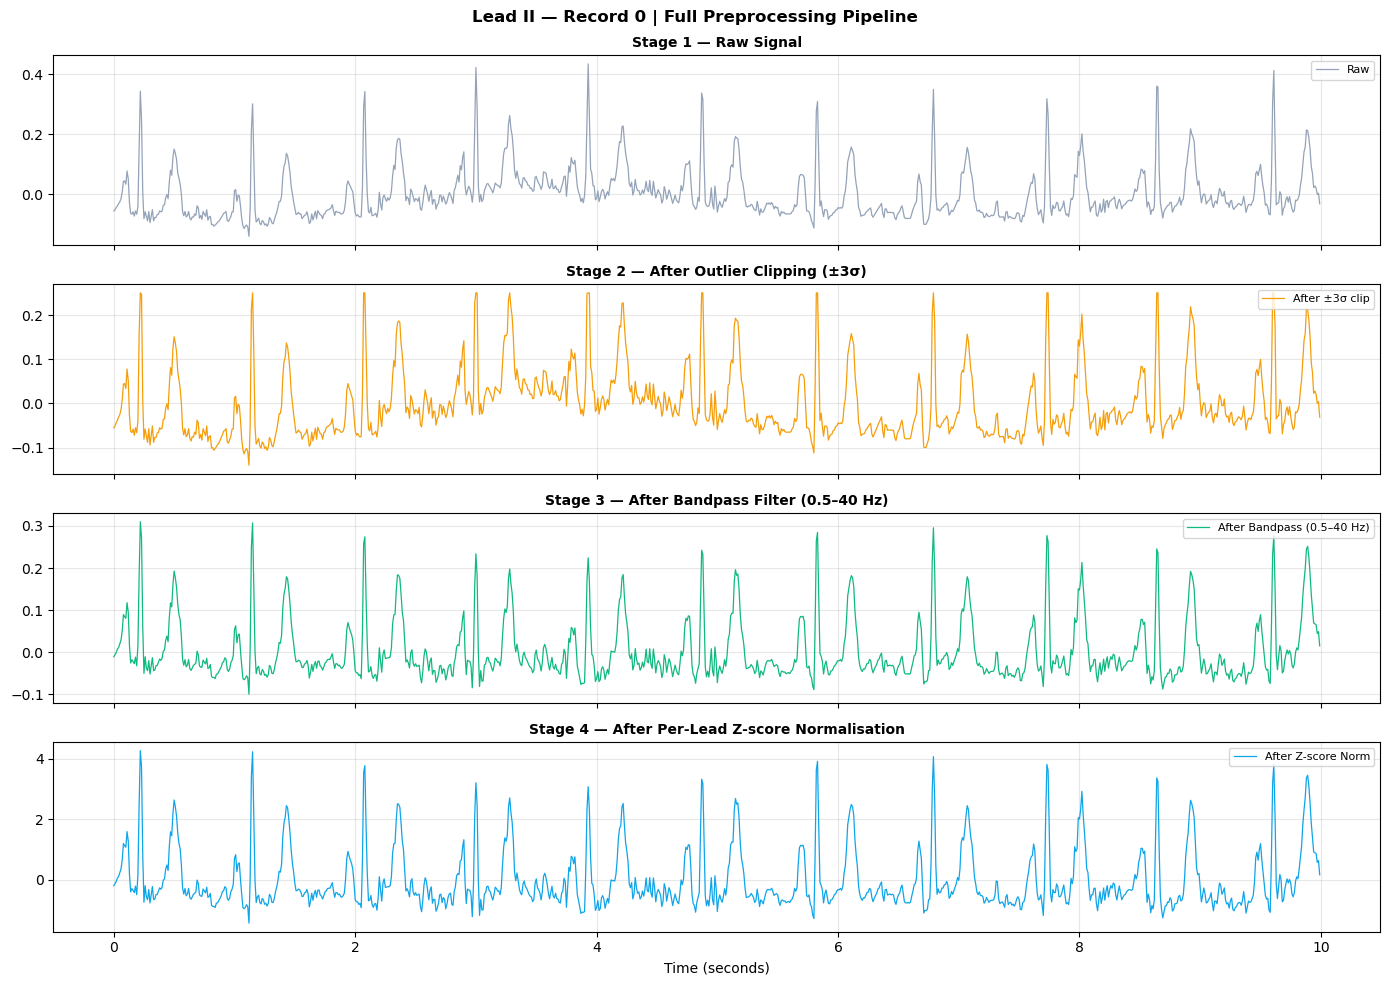

In [8]:
# ============================================================
# CELL 7: VISUALISE PIPELINE — RAW → CLIP → BANDPASS → NORM (Lead II)
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
t = np.arange(X_raw.shape[1]) / FS
lead_idx = 1   # Lead II

axes[0].plot(t, X_raw[0, :, lead_idx],      color='#94a3b8', lw=0.9, label='Raw')
axes[1].plot(t, X_clipped[0, :, lead_idx],  color='#f59e0b', lw=0.9, label='After ±3σ clip')
axes[2].plot(t, X_filtered[0, :, lead_idx], color='#10b981', lw=0.9, label='After Bandpass (0.5–40 Hz)')
axes[3].plot(t, X_norm[0, :, lead_idx],     color='#0ea5e9', lw=0.9, label='After Z-score Norm')

titles = [
    'Stage 1 — Raw Signal',
    'Stage 2 — After Outlier Clipping (±3σ)',
    'Stage 3 — After Bandpass Filter (0.5–40 Hz)',
    'Stage 4 — After Per-Lead Z-score Normalisation',
]
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
fig.suptitle('Lead II — Record 0 | Full Preprocessing Pipeline', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 6 — Sliding Window Segmentation
Each 10-second ECG is segmented into fixed-length overlapping windows.
- **Window size**: 500 samples (5 seconds at 100 Hz)
- **Stride**: 100 samples (1 second overlap between consecutive windows)
- Each window inherits the label of the original record.

In [9]:
# ============================================================
# CELL 8: SLIDING WINDOW SEGMENTATION
# Window size : 500 samples (5 s at 100 Hz)
# Stride      : 100 samples (1 s shift → ~80% overlap)
# ============================================================

WINDOW_SIZE = 500
STRIDE      = 100

def sliding_windows(X, y, window_size=500, stride=100):
    """
    Segment each record into overlapping windows.
    Each window inherits the label of the parent record.

    Returns
    -------
    X_windows : (total_windows, window_size, 12)
    y_windows : (total_windows, n_classes)
    """
    n_records, n_samples, n_leads = X.shape
    n_windows_per_record = (n_samples - window_size) // stride + 1

    X_windows = []
    y_windows = []

    for rec_idx in range(n_records):
        for w in range(n_windows_per_record):
            start = w * stride
            end   = start + window_size
            X_windows.append(X[rec_idx, start:end, :])
            y_windows.append(y[rec_idx])

    return np.array(X_windows), np.array(y_windows)

X_win, y_win = sliding_windows(X_norm, y_raw, WINDOW_SIZE, STRIDE)

n_per_rec = (X_norm.shape[1] - WINDOW_SIZE) // STRIDE + 1

print("=" * 55)
print("  SLIDING WINDOW SEGMENTATION")
print("=" * 55)
print(f"  Window size        : {WINDOW_SIZE} samples ({WINDOW_SIZE/FS:.1f}s)")
print(f"  Stride             : {STRIDE} samples ({STRIDE/FS:.1f}s)")
print(f"  Windows per record : {n_per_rec}")
print(f"  Total records      : {len(X_norm)}")
print(f"  Total windows      : {len(X_win)}  ({len(X_norm)} × {n_per_rec})")
print(f"  X_win shape        : {X_win.shape}")
print(f"  y_win shape        : {y_win.shape}")

  SLIDING WINDOW SEGMENTATION
  Window size        : 500 samples (5.0s)
  Stride             : 100 samples (1.0s)
  Windows per record : 6
  Total records      : 200
  Total windows      : 1200  (200 × 6)
  X_win shape        : (1200, 500, 12)
  y_win shape        : (1200, 5)


### Step 7 — Multi-Label Encoding Verification
Verify the multi-hot label matrix is correctly structured. Each record maps to a binary vector over the 5 diagnostic superclasses.

In [10]:
# ============================================================
# CELL 9: MULTI-LABEL ENCODING VERIFICATION
# ============================================================

print("=" * 55)
print("  MULTI-LABEL ENCODING CHECK")
print("=" * 55)
print(f"  Classes       : {CLASSES}")
print(f"  Label matrix  : {y_win.shape}  (windows × classes)")
print(f"  Label dtype   : {y_win.dtype}")
print(f"  Unique values : {np.unique(y_win)}")
print()

# Class frequency across windows
print(f"  {'Class':<8} {'Positive windows':>18} {'%':>8}")
print(f"  {'-'*38}")
for i, cls in enumerate(CLASSES):
    count = y_win[:, i].sum()
    pct   = 100 * count / len(y_win)
    bar   = '█' * int(pct // 3)
    print(f"  {cls:<8} {int(count):>18,} {pct:>7.1f}%  {bar}")

print()
print("  Sample label vectors (first 5 windows):")
header = '  ' + '  '.join(f'{c:<5}' for c in CLASSES)
print(header)
for row in y_win[:5]:
    print('  ' + '  '.join(f'{int(v):<5}' for v in row))

  MULTI-LABEL ENCODING CHECK
  Classes       : ['CD', 'HYP', 'MI', 'NORM', 'STTC']
  Label matrix  : (1200, 5)  (windows × classes)
  Label dtype   : int64
  Unique values : [0 1]

  Class      Positive windows        %
  --------------------------------------
  CD                      132    11.0%  ███
  HYP                      60     5.0%  █
  MI                      126    10.5%  ███
  NORM                    792    66.0%  ██████████████████████
  STTC                    162    13.5%  ████

  Sample label vectors (first 5 windows):
  CD     HYP    MI     NORM   STTC 
  0      0      0      1      0    
  0      0      0      1      0    
  0      0      0      1      0    
  0      0      0      1      0    
  0      0      0      1      0    


### Step 8 — Patient-Wise Train / Validation / Test Split
PTB-XL provides a pre-defined 10-fold stratified split where **all recordings from a single patient appear in only one fold**, guaranteeing no data leakage between subsets.

| Folds | Role |
|-------|------|
| 1–8 | Train |
| 9 | Validation |
| 10 | Test |

We replicate these folds to partition the windowed data.

In [11]:
# ============================================================
# CELL 10: PATIENT-WISE TRAIN / VAL / TEST SPLIT
# Using PTB-XL's official strat_fold to prevent data leakage.
# ============================================================

# Map each window back to the original record's strat_fold
WINDOW_SIZE  = 500
STRIDE       = 100
n_per_rec    = (X_norm.shape[1] - WINDOW_SIZE) // STRIDE + 1
record_folds = batch_df['strat_fold'].values  # shape (N_records,)

# Expand to windows: each record contributes n_per_rec windows
window_folds = np.repeat(record_folds, n_per_rec)  # shape (N_windows,)

train_mask = window_folds <= 8
val_mask   = window_folds == 9
test_mask  = window_folds == 10

X_train, y_train = X_win[train_mask], y_win[train_mask]
X_val,   y_val   = X_win[val_mask],   y_win[val_mask]
X_test,  y_test  = X_win[test_mask],  y_win[test_mask]

print("=" * 55)
print("  PATIENT-WISE SPLIT (via PTB-XL strat_fold)")
print("=" * 55)
print(f"  Total windows  : {len(X_win):,}")
print(f"  Train  (f 1-8) : {len(X_train):,}  ({100*len(X_train)/len(X_win):.1f}%)")
print(f"  Val    (f 9)   : {len(X_val):,}   ({100*len(X_val)/len(X_win):.1f}%)")
print(f"  Test   (f 10)  : {len(X_test):,}   ({100*len(X_test)/len(X_win):.1f}%)")
print()
print("  ✅ Patient-wise split ensures zero data leakage")

  PATIENT-WISE SPLIT (via PTB-XL strat_fold)
  Total windows  : 1,200
  Train  (f 1-8) : 762  (63.5%)
  Val    (f 9)   : 252   (21.0%)
  Test   (f 10)  : 186   (15.5%)

  ✅ Patient-wise split ensures zero data leakage


### Step 9 — Training-Time Data Augmentation
Applied **only to the training subset** to improve generalization. Four strategies are implemented:
- **Amplitude scaling** — random gain between 0.9–1.1×
- **Additive Gaussian noise** — SNR ≈ 20 dB
- **Temporal shifting** — random roll up to ±50 samples
- **Lead dropout** — randomly zero out 1–2 leads

Augmentation applied to training set:
  Original  X_train shape : (762, 500, 12)
  Augmented X_train shape : (762, 500, 12)

  Strategies applied:
    ✅ Amplitude scaling   — gain ∈ [0.9, 1.1]
    ✅ Gaussian noise      — σ = 0.02
    ✅ Temporal shifting   — roll ∈ [−50, +50] samples
    ✅ Lead dropout        — prob=0.10


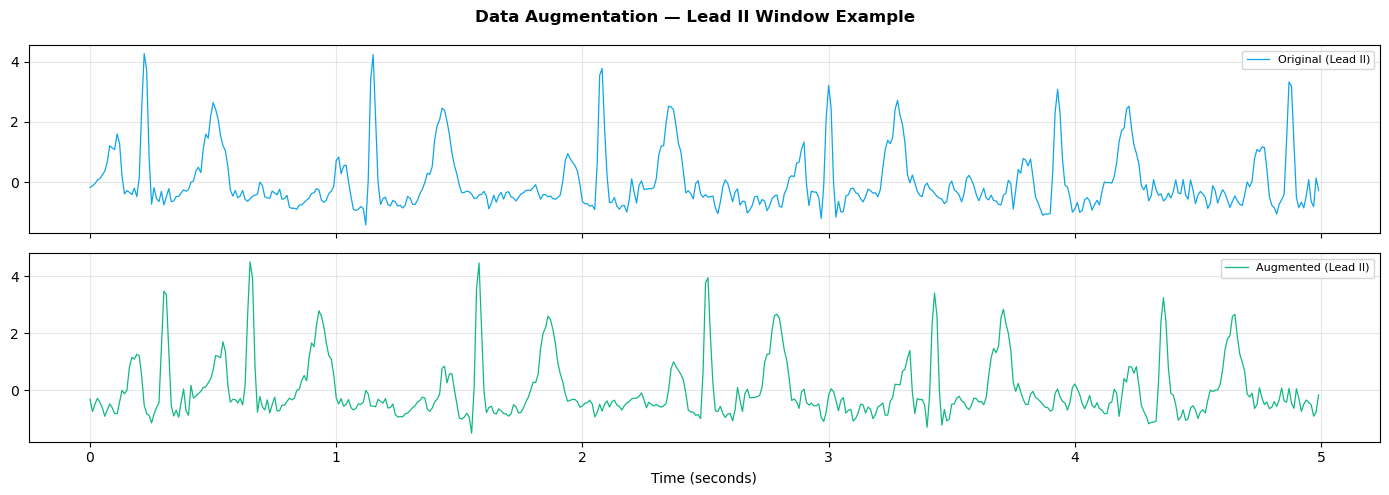

In [12]:
# ============================================================
# CELL 11: TRAINING-TIME DATA AUGMENTATION
# Applied ONLY to X_train — val/test are never augmented.
# ============================================================

RNG = np.random.default_rng(seed=42)   # reproducible

def augment_batch(X_batch, rng, noise_std=0.02, shift_max=50, drop_prob=0.1):
    """
    Apply 4 augmentation strategies to a batch of ECG windows.
    X_batch shape: (N, window_size, 12)
    """
    X_aug = X_batch.copy()
    N = len(X_aug)

    # 1. Amplitude scaling (gain ∈ [0.9, 1.1])
    scale = rng.uniform(0.9, 1.1, size=(N, 1, 1))
    X_aug *= scale

    # 2. Additive Gaussian noise
    noise = rng.normal(0, noise_std, size=X_aug.shape)
    X_aug += noise

    # 3. Temporal shifting (circular roll)
    shifts = rng.integers(-shift_max, shift_max + 1, size=N)
    for i, s in enumerate(shifts):
        if s != 0:
            X_aug[i] = np.roll(X_aug[i], s, axis=0)

    # 4. Lead dropout (zero out 1 random lead per record with prob drop_prob)
    for i in range(N):
        if rng.random() < drop_prob:
            lead_to_drop = rng.integers(0, 12)
            X_aug[i, :, lead_to_drop] = 0.0

    return X_aug

# ── Apply to training set ─────────────────────────────────────
X_train_aug = augment_batch(X_train, RNG)
# Labels stay the same — augmentation is signal-only
y_train_aug = y_train.copy()

print("Augmentation applied to training set:")
print(f"  Original  X_train shape : {X_train.shape}")
print(f"  Augmented X_train shape : {X_train_aug.shape}")
print()
print("  Strategies applied:")
print("    ✅ Amplitude scaling   — gain ∈ [0.9, 1.1]")
print("    ✅ Gaussian noise      — σ = 0.02")
print("    ✅ Temporal shifting   — roll ∈ [−50, +50] samples")
print("    ✅ Lead dropout        — prob=0.10")

# ── Quick visualisation of one augmented window ───────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
t = np.arange(WINDOW_SIZE) / FS

axes[0].plot(t, X_train[0, :, 1],     color='#0ea5e9', lw=0.9, label='Original (Lead II)')
axes[1].plot(t, X_train_aug[0, :, 1], color='#10b981', lw=0.9, label='Augmented (Lead II)')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Data Augmentation — Lead II Window Example', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 10 — Save Processed Arrays
Save all windowed splits to `data/processed/` for direct ingestion into the modeling and evaluation notebooks.

In [13]:
# ============================================================
# CELL 12: SAVE ALL PROCESSED OUTPUTS → data/processed/
# ============================================================

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Raw clean (pre-windowing) — used by 03_eda.ipynb ─────────
np.save(os.path.join(SAVE_DIR, 'X_clean.npy'), X_norm)

# ── Windowed splits (used by 04_modeling, 05_evaluation) ─────
np.save(os.path.join(SAVE_DIR, 'X_train.npy'), X_train_aug)
np.save(os.path.join(SAVE_DIR, 'y_train.npy'), y_train_aug)

np.save(os.path.join(SAVE_DIR, 'X_val.npy'),   X_val)
np.save(os.path.join(SAVE_DIR, 'y_val.npy'),   y_val)

np.save(os.path.join(SAVE_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(SAVE_DIR, 'y_test.npy'),  y_test)

# ── Config metadata ───────────────────────────────────────────
config = {
    'sampling_rate' : FS,
    'window_size'   : WINDOW_SIZE,
    'stride'        : STRIDE,
    'classes'       : CLASSES,
    'lead_names'    : LEAD_NAMES,
    'n_windows_per_record': n_per_rec,
}
with open(os.path.join(SAVE_DIR, 'config.pkl'), 'wb') as f:
    pickle.dump(config, f)

print("=" * 55)
print("  ALL OUTPUTS SAVED → data/processed/")
print("=" * 55)
saved = {
    'X_clean.npy' : X_norm.shape,
    'X_train.npy' : X_train_aug.shape,
    'y_train.npy' : y_train_aug.shape,
    'X_val.npy'   : X_val.shape,
    'y_val.npy'   : y_val.shape,
    'X_test.npy'  : X_test.shape,
    'y_test.npy'  : y_test.shape,
    'config.pkl'  : config,
}
for name, shape in saved.items():
    print(f"  {name:<18} → {shape}")

print()
print("✅ 02_preprocessing complete!")
print("   Next → 03_eda.ipynb (exploration) or 04_modeling.ipynb (training)")

  ALL OUTPUTS SAVED → data/processed/
  X_clean.npy        → (200, 1000, 12)
  X_train.npy        → (762, 500, 12)
  y_train.npy        → (762, 5)
  X_val.npy          → (252, 500, 12)
  y_val.npy          → (252, 5)
  X_test.npy         → (186, 500, 12)
  y_test.npy         → (186, 5)
  config.pkl         → {'sampling_rate': 100, 'window_size': 500, 'stride': 100, 'classes': ['CD', 'HYP', 'MI', 'NORM', 'STTC'], 'lead_names': ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], 'n_windows_per_record': 6}

✅ 02_preprocessing complete!
   Next → 03_eda.ipynb (exploration) or 04_modeling.ipynb (training)
